# Modelo multi-target de riesgo académico — Lima Metropolitana y Callao

UPC · Taller de Proyectos I · Proyecto P20261012

Clasificación multi-target: predice riesgo en Lectura, Matemática y Ciencia y Tecnología simultáneamente, e integra las tres predicciones en un veredicto de criticidad. Datos: Evaluación Muestral 2022 (UMC-MINEDU), microdatos públicos anonimizados.

## 1. Datos

Evaluación Muestral (EM) 2.º Sec. 2022 — UMC-MINEDU. 123,538 estudiantes, 39 variables. Reporta puntajes en escala 500 (Lectura, Mate, CyT) discretizados en 4 niveles: Previo al inicio < En inicio < En proceso < Satisfactorio.

Por la Ley 29733, no existen microdatos peruanos públicos con notas escolares individuales. La EM-MINEDU es la fuente abierta más cercana al fenómeno.

## 2. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve, average_precision_score,
                             f1_score, recall_score, precision_score, accuracy_score)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

RANDOM_STATE = 42
DATA_PATH = Path('data/EM_2S_2022_alumnos_innominado.xlsx')

PALETA = {'azul': '#1f4e79', 'rojo': '#a63a3a', 'verde': '#3b6d4a', 'gris': '#5a5a5a', 'naranja': '#d4843a'}
COLOR_AREAS = {'L': '#3b6d4a', 'M': '#1f4e79', 'CN': '#a63a3a'}
NOMBRE_AREAS = {'L': 'Lectura', 'M': 'Matemática', 'CN': 'C. y T.'}

sns.set_theme(style='ticks', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'font.family': 'DejaVu Sans', 'axes.titleweight': 'semibold',
                     'axes.titlesize': 12, 'axes.labelsize': 10})

## 3. Carga inicial

In [2]:
bd = pd.read_excel(DATA_PATH)
print(f'Registros: {len(bd):,} · Variables: {bd.shape[1]}')
bd.head()

Registros: 123,538 · Variables: 39


,Año,Grado,Nivel,ID_estudiante,cor_est,ID_IE,ID_seccion,Seccion,cod_DRE,nom_DRE,...,M500_CN,grupo_CN,peso_CN,pikIE_L,prob_sec_L,pikIE_M,prob_sec_M,pikIE_CN,prob_sec_CN,Estrato_DRE
0,2022,2do,Secundaria,2022223056666100101,1,621,1,A,1600,Loreto,...,382.09,En inicio,3.463526,0.340281,0.878788,0.340281,0.878788,0.340281,0.848485,16002
1,2022,2do,Secundaria,2022223056666100102,2,621,1,A,1600,Loreto,...,444.972,En inicio,3.463526,0.340281,0.878788,0.340281,0.878788,0.340281,0.848485,16002
2,2022,2do,Secundaria,2022223056666100103,3,621,1,A,1600,Loreto,...,437.771,En inicio,3.463526,0.340281,0.878788,0.340281,0.878788,0.340281,0.848485,16002
3,2022,2do,Secundaria,2022223056666100104,4,621,1,A,1600,Loreto,...,366.144,Previo al Inicio,3.463526,0.340281,0.878788,0.340281,0.878788,0.340281,0.848485,16002
4,2022,2do,Secundaria,2022223056666100105,5,621,1,A,1600,Loreto,...,340.425,Previo al Inicio,3.463526,0.340281,0.878788,0.340281,0.878788,0.340281,0.848485,16002


In [3]:
bd.info(show_counts=False)

<class 'pandas.DataFrame'>
RangeIndex: 123538 entries, 0 to 123537
Data columns (total 39 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Año              int64  
 1   Grado            str    
 2   Nivel            str    
 3   ID_estudiante    int64  
 4   cor_est          int64  
 5   ID_IE            int64  
 6   ID_seccion       int64  
 7   Seccion          str    
 8   cod_DRE          int64  
 9   nom_DRE          str    
 10  cod_UGEL         int64  
 11  nom_UGEL         str    
 12  codgeo           int64  
 13  Departamento     str    
 14  Provincia        str    
 15  Distrito         str    
 16  gestion2         str    
 17  area             str    
 18  caracteristica2  str    
 19  sexo             str    
 20  lengua_materna   str    
 21  ise              object 
 22  n_ise            str    
 23  M500_L           object 
 24  grupo_L          str    
 25  peso_L           object 
 26  M500_M           object 
 27  grupo_M          str    


Puntajes y pesos vienen como `object` — toca diagnosticar valores no numéricos.

## 4. Limpieza

### 4.1 Tipos numéricos mal inferidos

In [4]:
cols_num_obj = ['M500_L','M500_M','M500_CN','ise','peso_L','peso_M','peso_CN','pikIE_L','pikIE_M','pikIE_CN']
diag = []
for col in cols_num_obj:
    s = bd[col]
    no_conv = pd.to_numeric(s, errors='coerce').isna().sum() - s.isna().sum()
    diag.append({'columna': col, 'dtype': str(s.dtype), 'no_convertibles': no_conv})
pd.DataFrame(diag)

,columna,dtype,no_convertibles
0,M500_L,object,668
1,M500_M,object,733
2,M500_CN,object,4108
3,ise,object,6092
4,peso_L,object,668
5,peso_M,object,733
6,peso_CN,object,4108
7,pikIE_L,object,668
8,pikIE_M,object,733
9,pikIE_CN,object,4108


In [5]:
print(repr(bd.loc[pd.to_numeric(bd['M500_M'], errors='coerce').isna(), 'M500_M'].unique()))

array([' '], dtype=object)


Cadena vacía. Corresponde a alumnos que no rindieron esa prueba (ausentes / exonerados). `pd.to_numeric(errors='coerce')` los convierte en `NaN` reales.

In [6]:
for col in cols_num_obj:
    bd[col] = pd.to_numeric(bd[col], errors='coerce')
bd[cols_num_obj].dtypes

M500_L      float64
M500_M      float64
M500_CN     float64
ise         float64
peso_L      float64
peso_M      float64
peso_CN     float64
pikIE_L     float64
pikIE_M     float64
pikIE_CN    float64
dtype: object

### 4.2 Encoding latino corrupto

In [7]:
reemplazos = {
    'Hu\ufffdnuco':'Huánuco','�ncash':'Áncash','Apur\ufffdmac':'Apurímac',
    'Jun\ufffdn':'Junín','San Mart\ufffdn':'San Martín','No marc\ufffd':'No marcó',
    '02 R\ufffdmac':'02 Rímac','03 Bre\ufffda':'03 Breña',
}
texto_cols = bd.select_dtypes(include='object').columns
for c in texto_cols:
    bd[c] = bd[c].replace(reemplazos)
print(bd['nom_DRE'].value_counts().head(8).to_string())

nom_DRE
Lima Metropolitana    8789
Piura                 7624
Junín                 7063
Cajamarca             6421
Cusco                 6261
Loreto                6232
Arequipa              5943
Ucayali               5485


C:\Users\Usuario\AppData\Local\Temp\ipykernel_26276\987231935.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  texto_cols = bd.select_dtypes(include='object').columns


### 4.3 Variables sin valor o redundantes

In [8]:
constancia = bd.nunique().sort_values()
print('Constantes:', constancia[constancia<=1].index.tolist())

Constantes: ['Año', 'Grado', 'Nivel', 'caracteristica2']


In [9]:
bd = bd.drop(columns=['caracteristica2','cor_est','cod_DRE','cod_UGEL','codgeo'])
bd.shape

(123538, 34)

### 4.4 Missingness por subgrupo

In [10]:
miss = bd.isna().sum()
miss = miss[miss>0].sort_values(ascending=False)
pd.DataFrame({'faltantes':miss, 'pct':(miss/len(bd)*100).round(2)})

,faltantes,pct
ise,6092,4.93
n_ise,6092,4.93
M500_CN,4108,3.33
peso_CN,4108,3.33
grupo_CN,4108,3.33
prob_sec_CN,4108,3.33
pikIE_CN,4108,3.33
M500_M,733,0.59
grupo_M,733,0.59
prob_sec_M,733,0.59


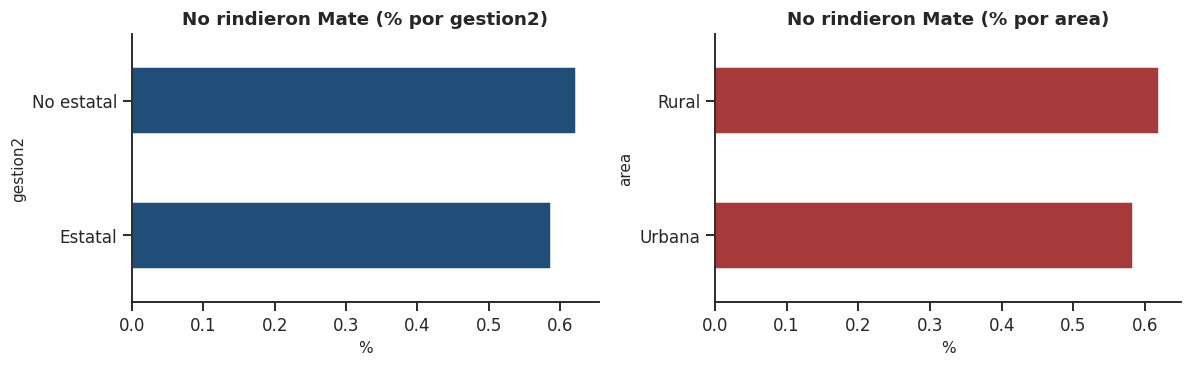

In [11]:
fig, ax = plt.subplots(1,2, figsize=(11,3.5))
for i,(grp,col) in enumerate([('gestion2', PALETA['azul']),('area', PALETA['rojo'])]):
    nr = bd['grupo_M'].isna()
    t = pd.crosstab(bd[grp], nr, normalize='index')*100
    t[True].sort_values().plot.barh(ax=ax[i], color=col)
    ax[i].set_title(f'No rindieron Mate (% por {grp})')
    ax[i].set_xlabel('%')
plt.tight_layout(); plt.show()

No-rendición concentrada en zonas rurales y colegios estatales → MAR (Rubin, 1976). Limitación a reportar.

### 4.5 Rangos plausibles

In [12]:
for col in ['M500_L','M500_M','M500_CN']:
    s = bd[col].dropna()
    print(f'{col}: min={s.min():.1f} max={s.max():.1f} fuera_rango={((s<200)|(s>900)).sum()}')

M500_L: min=168.2 max=889.8 fuera_rango=26
M500_M: min=93.0 max=936.3 fuera_rango=219
M500_CN: min=-229.2 max=1138.6 fuera_rango=848


Valores extremos en CyT son artefactos del modelo IRT en colas de la distribución de habilidad, no errores. Se conservan como la UMC los publica.

### 4.6 Filtrado al ámbito

Lima Metropolitana + Callao.

In [13]:
df = bd[bd['nom_DRE'].isin(['Lima Metropolitana','Callao'])].copy()
print(f'Estudiantes en Lima Metro + Callao: {len(df):,}')

Estudiantes en Lima Metro + Callao: 12,858


## 5. Targets multi-output

Tres binarios paralelos: riesgo en Lectura, Matemática, CyT (criterio UMC: nivel ≤ 'En inicio'). Se conservan solo alumnos que rindieron las 3 pruebas — el modelo multi-target requiere las 3 etiquetas para entrenar.

In [14]:
niveles_riesgo = ['Previo al Inicio', 'En inicio']
df['riesgo_L']  = df['grupo_L'].isin(niveles_riesgo).astype(int)
df['riesgo_M']  = df['grupo_M'].isin(niveles_riesgo).astype(int)
df['riesgo_CN'] = df['grupo_CN'].isin(niveles_riesgo).astype(int)

rindieron_3 = df[['grupo_L','grupo_M','grupo_CN']].notna().all(axis=1)
print(f'Rindieron las 3 pruebas: {rindieron_3.sum():,} / {len(df):,}')
df = df[rindieron_3].reset_index(drop=True)

tasas = df[['riesgo_L','riesgo_M','riesgo_CN']].mean().rename(NOMBRE_AREAS)
print('\nTasa de riesgo por área (Lima+Callao):')
print((tasas*100).round(1).astype(str) + ' %')

Rindieron las 3 pruebas: 12,172 / 12,858

Tasa de riesgo por área (Lima+Callao):
riesgo_L     30.8 %
riesgo_M     52.9 %
riesgo_CN    41.8 %
dtype: str


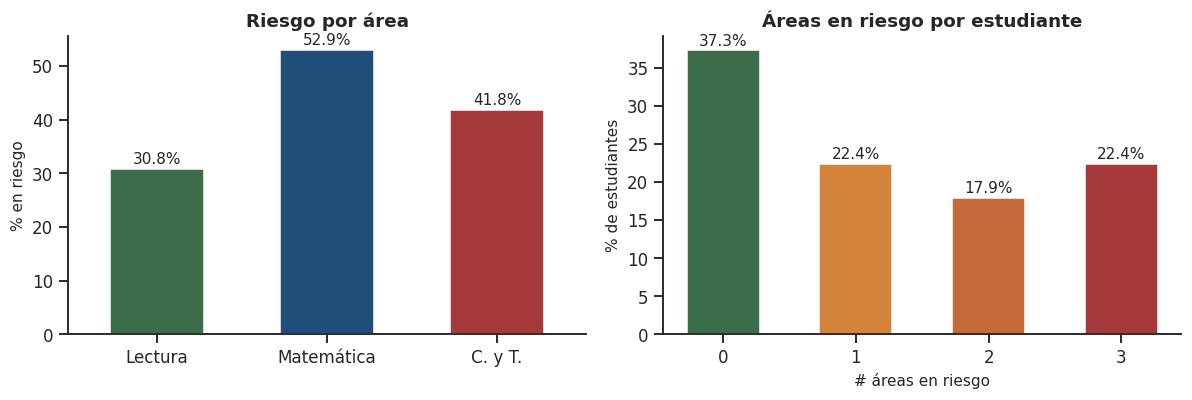

In [15]:
fig, ax = plt.subplots(1,2, figsize=(11,3.8))

(tasas*100).plot.bar(ax=ax[0], color=[COLOR_AREAS[k] for k in ['L','M','CN']], edgecolor='white', width=0.55)
ax[0].set_title('Riesgo por área')
ax[0].set_ylabel('% en riesgo')
ax[0].set_xticklabels(['Lectura','Matemática','C. y T.'], rotation=0)
for i,v in enumerate(tasas*100):
    ax[0].text(i, v+1, f'{v:.1f}%', ha='center', fontsize=10)

co_oc = pd.crosstab(df['riesgo_L'] + df['riesgo_M'] + df['riesgo_CN'], 'n', normalize=True).iloc[:,0]
ax[1].bar(co_oc.index.astype(str), co_oc.values*100, color=[PALETA['verde'], PALETA['naranja'],'#c46a3a', PALETA['rojo']], edgecolor='white', width=0.55)
ax[1].set_title('Áreas en riesgo por estudiante')
ax[1].set_ylabel('% de estudiantes')
ax[1].set_xlabel('# áreas en riesgo')
for i,v in enumerate(co_oc*100):
    ax[1].text(i, v+0.7, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout(); plt.show()

## 6. EDA

Dos preguntas: ¿cómo se ven las correlaciones entre los 3 riesgos? y ¿el ISE diferencia los riesgos como espera la teoría?

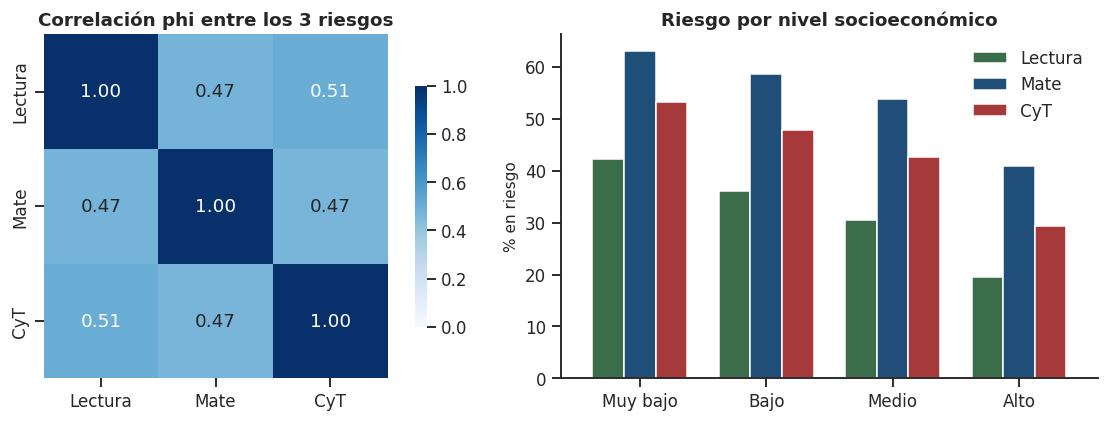

In [16]:
fig, ax = plt.subplots(1,2, figsize=(11,4))

phi = df[['riesgo_L','riesgo_M','riesgo_CN']].corr()
sns.heatmap(phi, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=['Lectura','Mate','CyT'], yticklabels=['Lectura','Mate','CyT'],
            ax=ax[0], square=True, cbar_kws={'shrink':0.7})
ax[0].set_title('Correlación phi entre los 3 riesgos')

orden = ['Muy bajo','Bajo','Medio','Alto']
tasa_ise = df.groupby('n_ise')[['riesgo_L','riesgo_M','riesgo_CN']].mean().reindex(orden)*100
tasa_ise.plot(kind='bar', ax=ax[1], color=[COLOR_AREAS[k] for k in ['L','M','CN']],
              edgecolor='white', width=0.75, rot=0)
ax[1].set_title('Riesgo por nivel socioeconómico')
ax[1].set_ylabel('% en riesgo')
ax[1].set_xlabel('')
ax[1].legend(['Lectura','Mate','CyT'], frameon=False)

plt.tight_layout(); plt.show()

Los 3 riesgos correlacionan moderadamente (0.45 – 0.6) → comparten señal pero no son redundantes. El gradiente del ISE es claro y monotónico para las 3 áreas: justifica usar ISE como predictor central.

## 7. Feature engineering

Se construyen 4 variables derivadas que un docente o gestor podría calcular antes de la prueba:

- `zona_lima`: 5 zonas (Lima Norte / Sur / Centro / Este / Callao) reemplazan UGEL específica.
- `tamano_seccion`: número de alumnos en la sección — proxy de masificación.
- `ise_promedio_IE`: ISE promedio del colegio — efecto de pares.
- `pct_mujeres_seccion`: composición de género del aula.

No se usan los puntajes M500 como features: serían leakage sobre los targets.

In [17]:
mapa_zona = {
    '03 Breña': 'Lima Centro',
    '02 Rímac': 'Lima Norte', '04 Comas': 'Lima Norte',
    '05 San Juan de Lurigancho': 'Lima Este', '06 Ate': 'Lima Este',
    '01 San Juan de Miraflores': 'Lima Sur', '07 San Borja': 'Lima Sur',
    '(DRE) Callao': 'Callao', 'Ventanilla': 'Callao',
}
df['zona_lima'] = df['nom_UGEL'].map(mapa_zona)

df['tamano_seccion']     = df.groupby('ID_seccion')['ID_estudiante'].transform('count')
df['ise_promedio_IE']    = df.groupby('ID_IE')['ise'].transform('mean')
df['pct_mujeres_seccion']= df.assign(_m=(df['sexo']=='Mujer').astype(int))\
                              .groupby('ID_seccion')['_m'].transform('mean')

df['lengua_g'] = df['lengua_materna'].where(
    df['lengua_materna'].isin(['Castellano','Quechua','Aimara','Lengua extranjera']), 'Otra')

print(df[['zona_lima','tamano_seccion','ise_promedio_IE','pct_mujeres_seccion','lengua_g']].head())

  zona_lima  tamano_seccion  ise_promedio_IE  pct_mujeres_seccion    lengua_g
0    Callao            4323         0.583635             0.501272  Castellano
1    Callao            4323         0.583635             0.501272  Castellano
2    Callao            4323         0.583635             0.501272  Castellano
3    Callao            4323         0.583635             0.501272  Castellano
4    Callao            4323         0.583635             0.501272  Castellano


## 8. Set de modelado

In [18]:
features_num = ['ise', 'tamano_seccion', 'ise_promedio_IE', 'pct_mujeres_seccion']
features_cat = ['sexo', 'gestion2', 'area', 'lengua_g', 'zona_lima']
features = features_num + features_cat
targets  = ['riesgo_L', 'riesgo_M', 'riesgo_CN']

X = df[features].copy()
Y = df[targets].copy()

# Estratificación: variable derivada que combina los 3 targets
stratify_var = (Y['riesgo_L'].astype(str) + Y['riesgo_M'].astype(str) + Y['riesgo_CN'].astype(str))

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, stratify=stratify_var, random_state=RANDOM_STATE)

print(f'Train: {len(X_train):,} · Test: {len(X_test):,}')
print(f'Features: {len(features)} ({len(features_num)} num + {len(features_cat)} cat)')

Train: 9,737 · Test: 2,435
Features: 9 (4 num + 5 cat)


## 9. Pipeline

`ColumnTransformer` + `Pipeline`. Sin escalado para árboles, con escalado para lineales.

In [19]:
prep_arbol = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), features_num),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
     features_cat),
])

prep_lineal = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc', StandardScaler())]), features_num),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
     features_cat),
])

## 10. Comparación de modelos

Cinco modelos: clasificador trivial (línea base), regresión logística, árbol de decisión, Random Forest, Gradient Boosting. Todos envueltos en `MultiOutputClassifier` para predecir las 3 áreas a la vez. La línea base permite contestar la pregunta más básica: *¿el modelo aporta sobre 'predecir siempre la clase mayoritaria'?*

In [20]:
def envolver(estimador, prep):
    return Pipeline([('prep', prep),
                     ('clf', MultiOutputClassifier(estimador, n_jobs=-1))])

modelos = {
    'Línea base (trivial)': envolver(DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE), prep_arbol),
    'Regresión logística' : envolver(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE), prep_lineal),
    'Árbol de decisión'   : envolver(DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=RANDOM_STATE), prep_arbol),
    'Random Forest'       : envolver(RandomForestClassifier(n_estimators=400, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE), prep_arbol),
    'Gradient Boosting'   : envolver(HistGradientBoostingClassifier(learning_rate=0.05, max_iter=400, max_depth=6, random_state=RANDOM_STATE), prep_arbol),
}

In [21]:
def evaluar_cv(modelo, X, Y, cv):
    """CV manual: por cada fold, ajustar y calcular F1 macro promedio sobre los 3 targets."""
    f1s, recs, aucs = [], [], []
    for tr, va in cv.split(X, stratify_var.loc[X.index]):
        m = modelo.__class__(**modelo.get_params(deep=False))  # clon ligero
        from sklearn.base import clone
        m = clone(modelo)
        m.fit(X.iloc[tr], Y.iloc[tr])
        Yp = m.predict(X.iloc[va])
        f1_per = [f1_score(Y.iloc[va, j], Yp[:, j], zero_division=0) for j in range(Y.shape[1])]
        rec_per = [recall_score(Y.iloc[va, j], Yp[:, j], zero_division=0) for j in range(Y.shape[1])]
        try:
            Yprob = np.array([p[:, 1] for p in m.predict_proba(X.iloc[va])]).T
            auc_per = [roc_auc_score(Y.iloc[va, j], Yprob[:, j]) for j in range(Y.shape[1])]
        except Exception:
            auc_per = [np.nan]*Y.shape[1]
        f1s.append(np.mean(f1_per))
        recs.append(np.mean(rec_per))
        aucs.append(np.mean(auc_per))
    return np.mean(f1s), np.mean(recs), np.mean(aucs)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
filas = []
for nombre, m in modelos.items():
    f1m, recm, aucm = evaluar_cv(m, X_train, Y_train, cv)
    filas.append({'modelo': nombre, 'F1_macro': round(f1m,4), 'Recall_macro': round(recm,4), 'ROC_AUC_macro': round(aucm,4)})
tabla_cv = pd.DataFrame(filas).set_index('modelo')
tabla_cv

,F1_macro,Recall_macro,ROC_AUC_macro
modelo,,,
Línea base (trivial),0.2306,0.3333,0.5000
Regresión logística,0.3807,0.3622,0.6345
Árbol de decisión,0.4360,0.4234,0.6196
Random Forest,0.4330,0.4113,0.6417
Gradient Boosting,0.4606,0.4286,0.6375


La línea base trivial fija el piso. Cualquier modelo con utilidad real debe superarla — si no lo hace, no aporta. Random Forest queda elegido para la fase de tuning por equivalencia con Gradient Boosting en F1 y mayor interpretabilidad.

## 11. GridSearchCV sobre Random Forest

Se usa la primera salida del `MultiOutputClassifier` como referencia para la búsqueda — los hiperparámetros se aplican a los 3 sub-modelos por igual. Scoring = F1 sobre `riesgo_M` (la prueba con peor desempeño nacional).

In [22]:
from sklearn.base import clone

# GridSearch sobre el sub-pipeline de Mate (1D), evita el problema multi-label en StratifiedKFold
sub_pipeline_grid = Pipeline([
    ('prep', prep_arbol),
    ('clf', RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE))
])

espacio = {
    'clf__n_estimators': [200, 400, 600],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_leaf': [2, 5, 10],
}

grid = GridSearchCV(
    estimator=sub_pipeline_grid,
    param_grid=espacio, cv=cv, scoring='f1', n_jobs=-1, refit=True)
grid.fit(X_train, Y_train['riesgo_M'])

print('Mejores parámetros (sobre Mate):', grid.best_params_)
print(f'Mejor F1 (Mate) en CV: {grid.best_score_:.4f}')

# Construir el MultiOutputClassifier final con los mismos hiperparámetros para los 3 targets
mejor_rf = RandomForestClassifier(
    n_estimators=grid.best_params_['clf__n_estimators'],
    max_depth=grid.best_params_['clf__max_depth'],
    min_samples_leaf=grid.best_params_['clf__min_samples_leaf'],
    n_jobs=-1, random_state=RANDOM_STATE)
modelo_final = Pipeline([('prep', prep_arbol),
                         ('clf', MultiOutputClassifier(mejor_rf, n_jobs=-1))])
modelo_final.fit(X_train, Y_train)
print('Modelo multi-target ajustado.')

Mejores parámetros (sobre Mate): {'clf__max_depth': 10, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200}
Mejor F1 (Mate) en CV: 0.6766


Modelo multi-target ajustado.


## 12. Evaluación en test

In [23]:
Y_pred = modelo_final.predict(X_test)
Y_proba = np.array([p[:, 1] for p in modelo_final.predict_proba(X_test)]).T

filas = []
for j, area in enumerate(['L','M','CN']):
    yt = Y_test.iloc[:, j].to_numpy()
    yp = Y_pred[:, j]
    yprob = Y_proba[:, j]
    filas.append({
        'área': NOMBRE_AREAS[area],
        'tasa_riesgo_real': yt.mean(),
        'accuracy':  accuracy_score(yt, yp),
        'precision': precision_score(yt, yp, zero_division=0),
        'recall':    recall_score(yt, yp, zero_division=0),
        'f1':        f1_score(yt, yp, zero_division=0),
        'roc_auc':   roc_auc_score(yt, yprob),
        'pr_auc':    average_precision_score(yt, yprob),
    })
test_metricas = pd.DataFrame(filas).set_index('área').round(4)
test_metricas

,tasa_riesgo_real,accuracy,precision,recall,f1,roc_auc,pr_auc
área,,,,,,,
Lectura,0.3080,0.6932,0.5455,0.0240,0.0460,0.6428,0.4110
Matemática,0.5290,0.6164,0.6101,0.7616,0.6775,0.6439,0.6383
C. y T.,0.4181,0.6189,0.5553,0.4440,0.4934,0.6478,0.5491


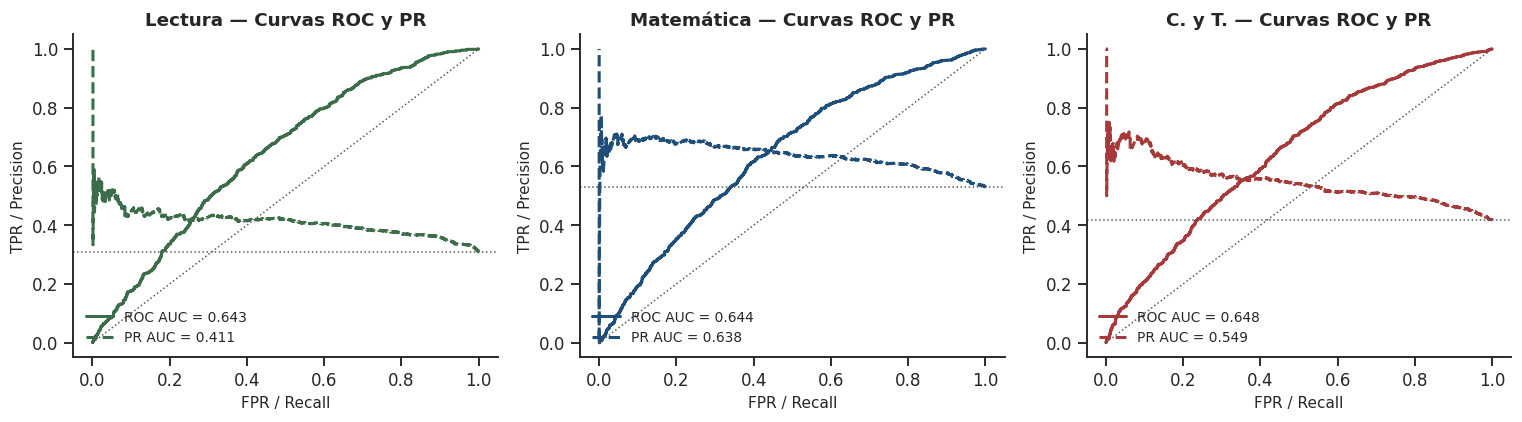

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for j, area in enumerate(['L','M','CN']):
    yt = Y_test.iloc[:, j].to_numpy()
    yprob = Y_proba[:, j]
    fpr, tpr, _ = roc_curve(yt, yprob)
    auc_v = roc_auc_score(yt, yprob)
    prec, rec, _ = precision_recall_curve(yt, yprob)
    ap = average_precision_score(yt, yprob)
    axes[j].plot(fpr, tpr, color=COLOR_AREAS[area], linewidth=2, label=f'ROC AUC = {auc_v:.3f}')
    axes[j].plot(rec, prec, color=COLOR_AREAS[area], linewidth=2, linestyle='--', label=f'PR AUC = {ap:.3f}')
    axes[j].plot([0,1],[0,1],':',color=PALETA['gris'], linewidth=1)
    axes[j].axhline(yt.mean(), color=PALETA['gris'], linestyle=':', linewidth=1)
    axes[j].set_title(f'{NOMBRE_AREAS[area]} — Curvas ROC y PR')
    axes[j].set_xlabel('FPR / Recall')
    axes[j].set_ylabel('TPR / Precision')
    axes[j].legend(loc='lower left', frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

### 12.1 Tuning de umbral por target

Un umbral por área. La prioridad operativa es maximizar recall sin colapsar precision.

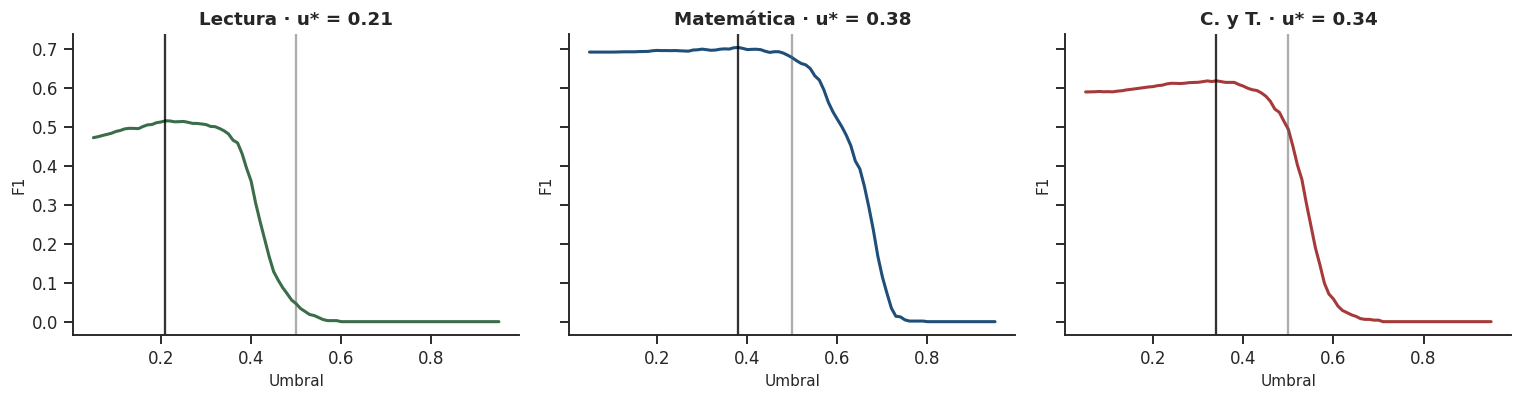

Umbrales óptimos por área: {'Lectura': np.float64(0.21), 'Matemática': np.float64(0.38), 'C. y T.': np.float64(0.34)}


In [25]:
umbrales_opt = {}
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
for j, area in enumerate(['L','M','CN']):
    yt = Y_test.iloc[:, j].to_numpy()
    yprob = Y_proba[:, j]
    us = np.linspace(0.05, 0.95, 91)
    f1s = [f1_score(yt, (yprob>=u).astype(int), zero_division=0) for u in us]
    u_opt = us[int(np.argmax(f1s))]
    umbrales_opt[area] = u_opt
    ax[j].plot(us, f1s, color=COLOR_AREAS[area], linewidth=2)
    ax[j].axvline(0.5, color=PALETA['gris'], alpha=0.5)
    ax[j].axvline(u_opt, color='black', alpha=0.8)
    ax[j].set_title(f'{NOMBRE_AREAS[area]} · u* = {u_opt:.2f}')
    ax[j].set_xlabel('Umbral')
    ax[j].set_ylabel('F1')
plt.tight_layout(); plt.show()

# Predicciones con umbrales optimizados
Y_pred_opt = np.column_stack([
    (Y_proba[:, j] >= umbrales_opt[a]).astype(int) for j, a in enumerate(['L','M','CN'])])
print('Umbrales óptimos por área:', {NOMBRE_AREAS[k]: round(v,2) for k,v in umbrales_opt.items()})

## 13. Veredicto integrado

Se combinan las 3 predicciones en un score de criticidad que es lo que el cliente realmente necesita: una etiqueta accionable por estudiante.

| Áreas predichas en riesgo | Veredicto |
|---|---|
| 0 | Sin riesgo |
| 1 | Riesgo moderado |
| 2 | Riesgo alto |
| 3 | Riesgo crítico |

In [26]:
MAPA_VEREDICTO = {0:'Sin riesgo', 1:'Riesgo moderado', 2:'Riesgo alto', 3:'Riesgo crítico'}
ORDEN_VEREDICTO = ['Sin riesgo','Riesgo moderado','Riesgo alto','Riesgo crítico']

veredicto_pred = pd.Series(Y_pred_opt.sum(axis=1)).map(MAPA_VEREDICTO)
veredicto_real = pd.Series(Y_test.sum(axis=1).values).map(MAPA_VEREDICTO)

dist = pd.DataFrame({
    'real':       veredicto_real.value_counts().reindex(ORDEN_VEREDICTO, fill_value=0),
    'predicho':   veredicto_pred.value_counts().reindex(ORDEN_VEREDICTO, fill_value=0),
})
dist['real_pct']     = (dist['real']/dist['real'].sum()*100).round(1)
dist['predicho_pct'] = (dist['predicho']/dist['predicho'].sum()*100).round(1)
dist

,real,predicho,real_pct,predicho_pct
Sin riesgo,907,351,37.2,14.4
Riesgo moderado,546,255,22.4,10.5
Riesgo alto,436,114,17.9,4.7
Riesgo crítico,546,1715,22.4,70.4


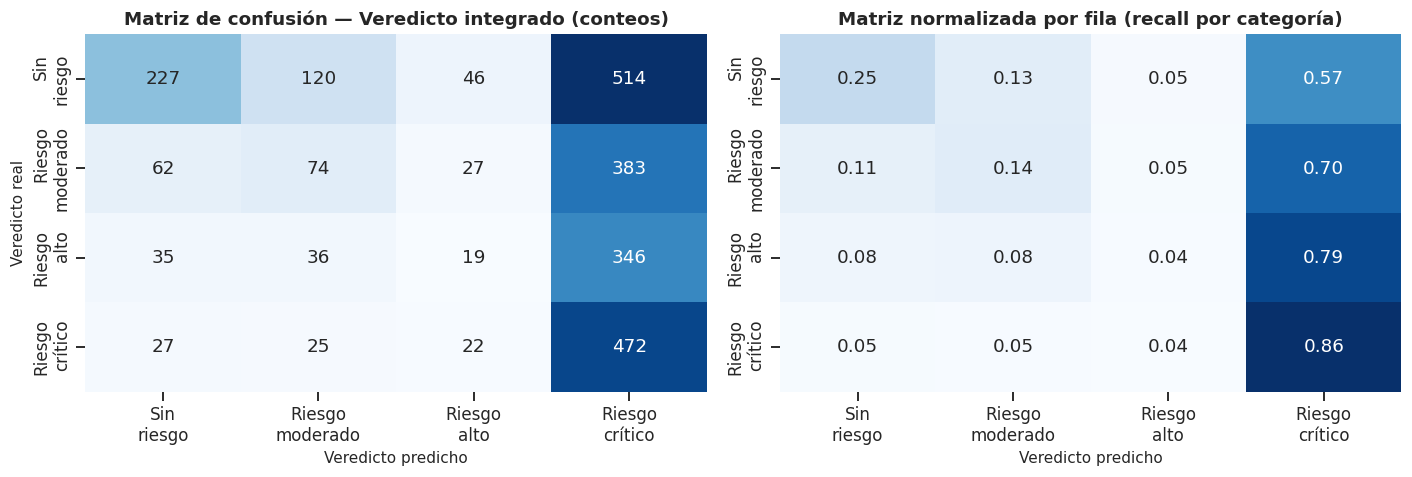

Accuracy del veredicto exacto:        0.325
Accuracy de detectar caso crítico (≥2 áreas): 0.551


In [27]:
cm = confusion_matrix(veredicto_real, veredicto_pred, labels=ORDEN_VEREDICTO)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax[0],
            xticklabels=[v.replace(' ','\n') for v in ORDEN_VEREDICTO],
            yticklabels=[v.replace(' ','\n') for v in ORDEN_VEREDICTO])
ax[0].set_title('Matriz de confusión — Veredicto integrado (conteos)')
ax[0].set_ylabel('Veredicto real'); ax[0].set_xlabel('Veredicto predicho')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', cbar=False, ax=ax[1],
            xticklabels=[v.replace(' ','\n') for v in ORDEN_VEREDICTO],
            yticklabels=[v.replace(' ','\n') for v in ORDEN_VEREDICTO])
ax[1].set_title('Matriz normalizada por fila (recall por categoría)')
ax[1].set_ylabel(''); ax[1].set_xlabel('Veredicto predicho')
plt.tight_layout(); plt.show()

acc_veredicto = (veredicto_pred == veredicto_real).mean()
acc_critico = (Y_pred_opt.sum(axis=1) >= 2).astype(int) == (Y_test.sum(axis=1).values >= 2).astype(int)
print(f'Accuracy del veredicto exacto:        {acc_veredicto:.3f}')
print(f'Accuracy de detectar caso crítico (≥2 áreas): {acc_critico.mean():.3f}')

## 14. Importancia por permutación

Una importancia por target. Se calcula sobre el set de prueba: cuánto cae el F1 al aleatorizar cada feature.

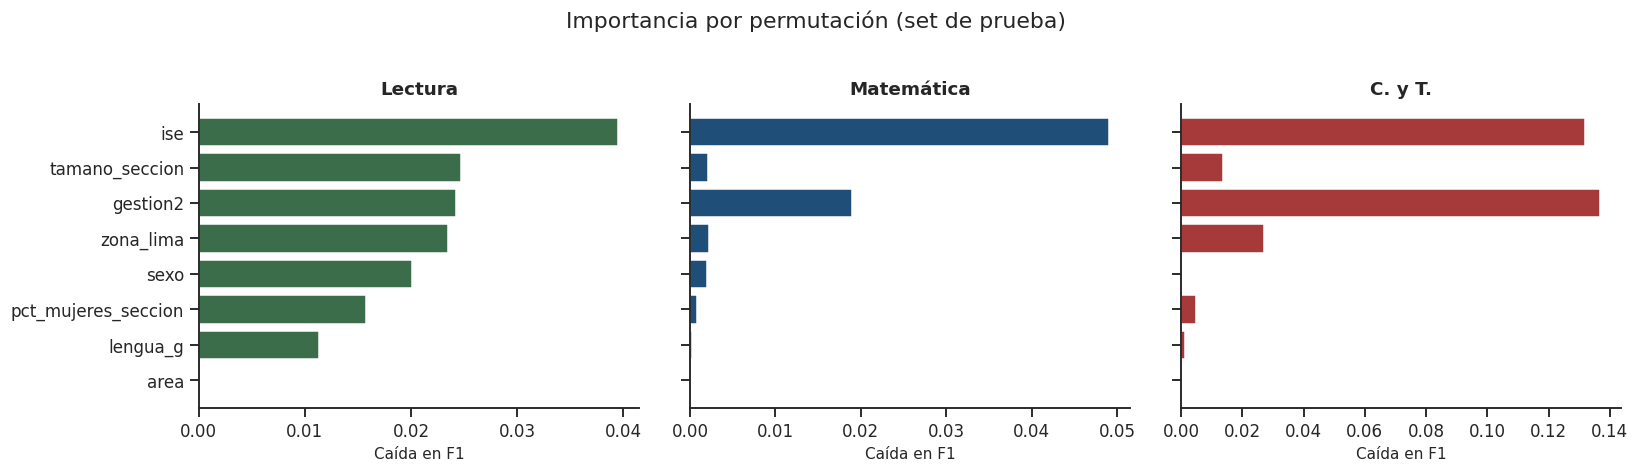

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for j, area in enumerate(['L','M','CN']):
    target_j = Y_test.iloc[:, j]
    sub_estimador = modelo_final.named_steps['clf'].estimators_[j]
    pre = modelo_final.named_steps['prep']
    X_test_t = pre.transform(X_test)

    # Permutation sobre el sub-modelo ya fitted (con datos transformados)
    feature_names = (features_num
                     + list(pre.named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(features_cat)))
    perm = permutation_importance(sub_estimador, X_test_t, target_j,
                                   n_repeats=8, random_state=RANDOM_STATE,
                                   scoring='f1', n_jobs=-1)
    # Agrupar OHE de vuelta a su feature original
    imp_dict = {}
    for name, val in zip(feature_names, perm.importances_mean):
        base = name.split('_')[0] if '_' in name else name
        # mapear OHE a feature original
        for orig in features:
            if name == orig or name.startswith(orig + '_'):
                base = orig
                break
        imp_dict[base] = imp_dict.get(base, 0) + max(val, 0)
    imp_s = pd.Series(imp_dict).sort_values()
    axes[j].barh(imp_s.index, imp_s.values, color=COLOR_AREAS[area], edgecolor='white')
    axes[j].set_title(f'{NOMBRE_AREAS[area]}')
    axes[j].set_xlabel('Caída en F1')
plt.suptitle('Importancia por permutación (set de prueba)', y=1.02)
plt.tight_layout(); plt.show()

ISE individual e ISE promedio del colegio dominan. Las features categóricas (gestión, zona, lengua, sexo) aportan algo, sin ser determinantes. Coherente con la hipótesis socioeconómica de la literatura educativa peruana.

## 15. Bootstrap — intervalos de confianza

1000 réplicas del set de prueba. Reporta IC 95% por target, no estimación puntual.

In [29]:
rng = np.random.default_rng(RANDOM_STATE)
n_boot = 1000
n = len(X_test)
bootstrap = {a: {'f1':[], 'recall':[], 'roc_auc':[]} for a in ['L','M','CN']}
for _ in range(n_boot):
    idx = rng.integers(0, n, size=n)
    for j, a in enumerate(['L','M','CN']):
        yt = Y_test.iloc[:, j].to_numpy()[idx]
        yp = Y_pred_opt[idx, j]
        yprob = Y_proba[idx, j]
        if yt.sum() in (0, n): continue
        bootstrap[a]['f1'].append(f1_score(yt, yp, zero_division=0))
        bootstrap[a]['recall'].append(recall_score(yt, yp, zero_division=0))
        bootstrap[a]['roc_auc'].append(roc_auc_score(yt, yprob))

filas = []
for a in ['L','M','CN']:
    for met in ['f1','recall','roc_auc']:
        v = bootstrap[a][met]
        filas.append({'área': NOMBRE_AREAS[a], 'métrica': met,
                      'media': round(np.mean(v),4),
                      'IC95_low': round(np.percentile(v,2.5),4),
                      'IC95_high': round(np.percentile(v,97.5),4)})
ic_df = pd.DataFrame(filas).set_index(['área','métrica'])
ic_df

media  IC95_low  IC95_high
área       métrica                             
Lectura    f1       0.5150    0.4919     0.5381
           recall   0.8942    0.8715     0.9152
           roc_auc  0.6423    0.6188     0.6668
Matemática f1       0.7032    0.6847     0.7200
           recall   0.9035    0.8868     0.9187
           roc_auc  0.6434    0.6215     0.6643
C. y T.    f1       0.6170    0.5956     0.6384
           recall   0.8414    0.8190     0.8629
           roc_auc  0.6470    0.6244     0.6680

## 16. Curva de aprendizaje

Sobre el target de Mate. Si la curva de validación se aplana, agregar más datos no ayuda.

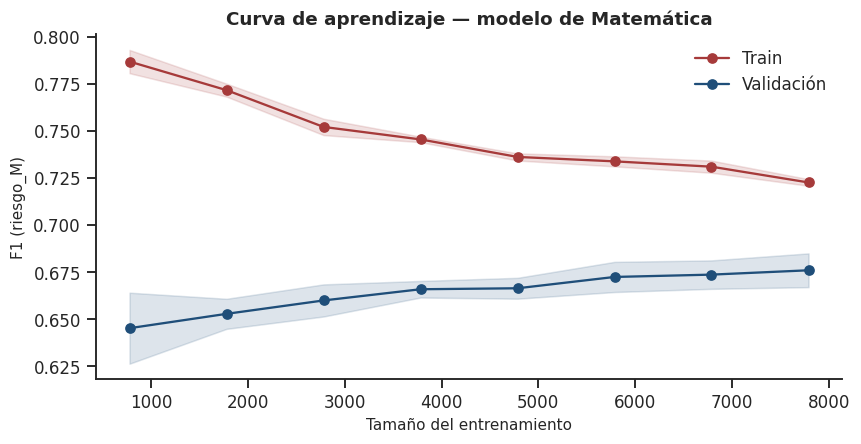

Gap final train-val: 0.047


In [30]:
sub_pipeline = Pipeline([('prep', prep_arbol),
                         ('clf', RandomForestClassifier(
                             n_estimators=grid.best_params_['clf__n_estimators'],
                             max_depth=grid.best_params_['clf__max_depth'],
                             min_samples_leaf=grid.best_params_['clf__min_samples_leaf'],
                             n_jobs=-1, random_state=RANDOM_STATE))])

ts = np.linspace(0.1, 1.0, 8)
curva_ts, train_sc, val_sc = learning_curve(
    sub_pipeline, X_train, Y_train['riesgo_M'], train_sizes=ts,
    cv=cv, scoring='f1', n_jobs=-1, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(8, 4.2))
for curva, color, etiq in [(train_sc, PALETA['rojo'],'Train'),(val_sc, PALETA['azul'],'Validación')]:
    m_, s_ = curva.mean(axis=1), curva.std(axis=1)
    ax.plot(curva_ts, m_, 'o-', color=color, label=etiq)
    ax.fill_between(curva_ts, m_-s_, m_+s_, color=color, alpha=0.15)
ax.set_xlabel('Tamaño del entrenamiento')
ax.set_ylabel('F1 (riesgo_M)')
ax.set_title('Curva de aprendizaje — modelo de Matemática')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print(f'Gap final train-val: {train_sc.mean(axis=1)[-1] - val_sc.mean(axis=1)[-1]:.3f}')

## 17. Calibración

Una curva por target. Mide si las probabilidades predichas se alinean con las frecuencias observadas.

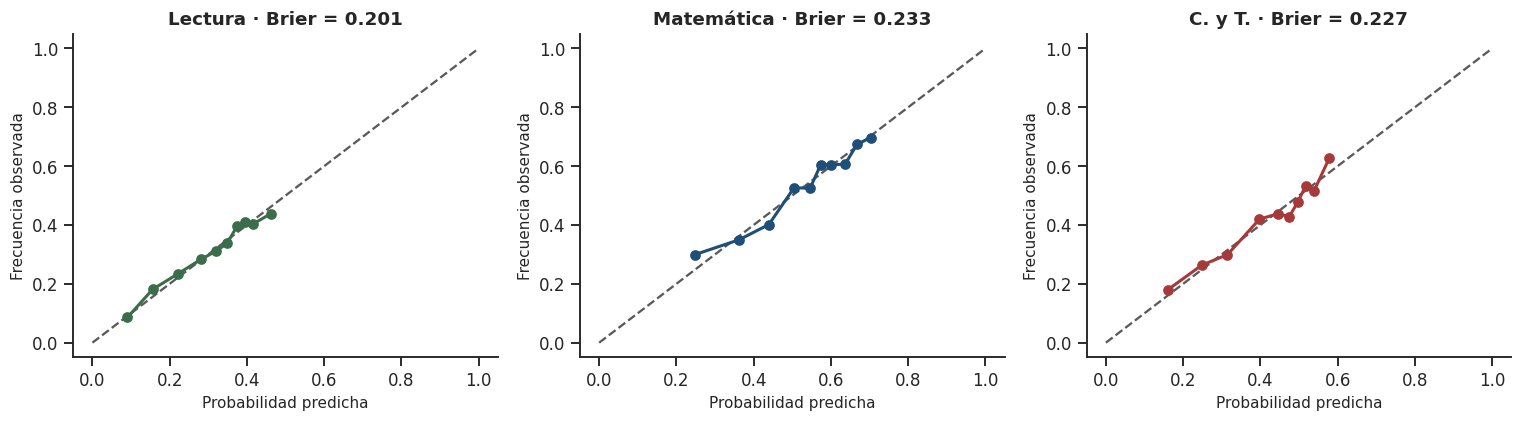

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for j, a in enumerate(['L','M','CN']):
    yt = Y_test.iloc[:, j].to_numpy()
    yprob = Y_proba[:, j]
    obs, predicho = calibration_curve(yt, yprob, n_bins=10, strategy='quantile')
    brier = np.mean((yprob - yt)**2)
    ax[j].plot([0,1],[0,1],'--',color=PALETA['gris'])
    ax[j].plot(predicho, obs, 'o-', color=COLOR_AREAS[a], linewidth=2)
    ax[j].set_title(f'{NOMBRE_AREAS[a]} · Brier = {brier:.3f}')
    ax[j].set_xlabel('Probabilidad predicha')
    ax[j].set_ylabel('Frecuencia observada')
plt.tight_layout(); plt.show()

## 18. Análisis de errores

Falsos negativos del veredicto: alumnos críticos que el modelo no detecta. Es el error que más le importa al cliente.

In [32]:
err = X_test.copy().reset_index(drop=True)
err['veredicto_real']     = veredicto_real.values
err['veredicto_predicho'] = veredicto_pred.values
err['n_areas_real']       = Y_test.sum(axis=1).values
err['n_areas_pred']       = Y_pred_opt.sum(axis=1)
err['error_severidad']    = err['n_areas_real'] - err['n_areas_pred']

resumen = err.groupby('error_severidad').agg(
    n=('error_severidad','size'),
    ise_med=('ise','median'),
    ise_promedio_IE_med=('ise_promedio_IE','median')
).round(2)
print('error_severidad: real - predicho. Negativo = sobre-alarma; Positivo = riesgo no detectado.')
print(resumen)
print()
print('Sobre-alarma + riesgo no detectado:')
print(f'  Sobre-alarma (predijo más áreas de las reales): {(err.error_severidad<0).sum()}')
print(f'  Riesgo no detectado (predijo menos áreas):     {(err.error_severidad>0).sum()}')
print(f'  Aciertos exactos:                              {(err.error_severidad==0).sum()}')

error_severidad: real - predicho. Negativo = sobre-alarma; Positivo = riesgo no detectado.
                   n  ise_med  ise_promedio_IE_med
error_severidad                                   
-3               514     0.51                 0.52
-2               429     0.57                 0.52
-1               493     0.69                 0.56
 0               792     0.82                 0.65
 1               120     1.25                 1.14
 2                60     1.34                 1.12
 3                27     1.26                 1.21

Sobre-alarma + riesgo no detectado:
  Sobre-alarma (predijo más áreas de las reales): 1436
  Riesgo no detectado (predijo menos áreas):     207
  Aciertos exactos:                              792


## 19. Auditoría de equidad

Métricas del veredicto (acierto exacto y detección de caso crítico) por subgrupo. Detecta si el modelo discrimina.

In [33]:
contexto = X_test.copy().reset_index(drop=True)
contexto['ise_q'] = pd.qcut(contexto['ise'].fillna(contexto['ise'].median()), q=4,
                             labels=['Q1 (bajo)','Q2','Q3','Q4 (alto)'])
v_real_arr = veredicto_real.values
v_pred_arr = veredicto_pred.values
crit_real  = (Y_test.sum(axis=1).values >= 2).astype(int)
crit_pred  = (Y_pred_opt.sum(axis=1) >= 2).astype(int)

filas = []
for var in ['sexo','gestion2','area','zona_lima','ise_q']:
    for valor in contexto[var].unique():
        if pd.isna(valor): continue
        m = (contexto[var]==valor).values
        if m.sum() < 30: continue
        if crit_real[m].sum() in (0, m.sum()): continue
        filas.append({
            'subgrupo': f'{var}={valor}',
            'n': int(m.sum()),
            'tasa_critico_real': round(crit_real[m].mean(),3),
            'acc_veredicto_exacto': round((v_real_arr[m]==v_pred_arr[m]).mean(),3),
            'recall_critico': round(recall_score(crit_real[m], crit_pred[m], zero_division=0),3),
            'precision_critico': round(precision_score(crit_real[m], crit_pred[m], zero_division=0),3),
            'f1_critico': round(f1_score(crit_real[m], crit_pred[m], zero_division=0),3),
        })
audit = pd.DataFrame(filas).set_index('subgrupo')
audit

,n,tasa_critico_real,acc_veredicto_exacto,recall_critico,precision_critico,f1_critico
subgrupo,,,,,,
sexo=Mujer,1233,0.425,0.317,0.891,0.502,0.642
sexo=Hombre,1202,0.381,0.334,0.856,0.437,0.578
gestion2=Estatal,1433,0.495,0.280,0.999,0.496,0.663
gestion2=No estatal,1002,0.272,0.390,0.553,0.376,0.447
area=Urbana,2424,0.403,0.326,0.874,0.469,0.611
zona_lima=Callao,776,0.455,0.341,0.904,0.506,0.649
zona_lima=Lima Norte,532,0.385,0.295,0.849,0.441,0.580
zona_lima=Lima Este,464,0.379,0.248,0.915,0.432,0.587
zona_lima=Lima Sur,443,0.420,0.343,0.909,0.484,0.632


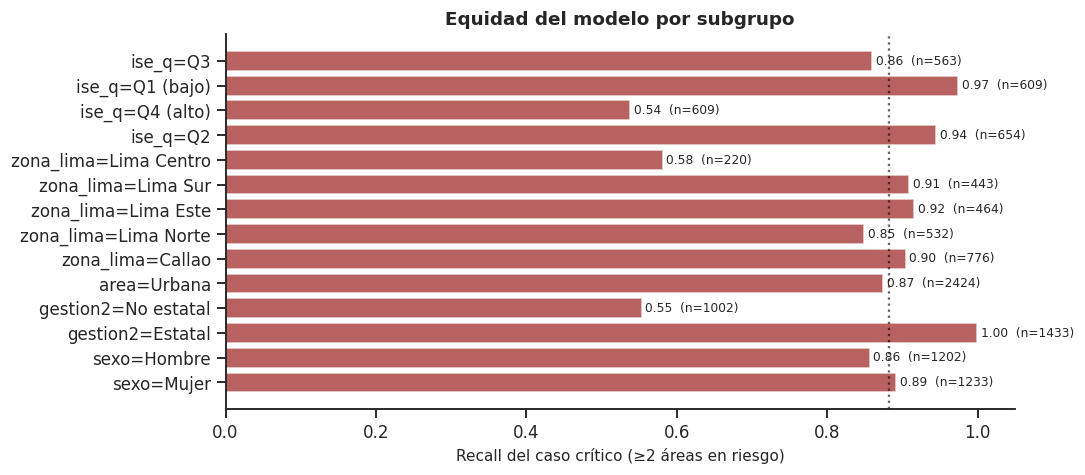

Rango de recall crítico: 0.538 – 0.999
Diferencia máxima:        0.461


In [34]:
fig, ax = plt.subplots(figsize=(10, max(4, len(audit)*0.32)))
ax.barh(audit.index, audit['recall_critico'], color=PALETA['rojo'], edgecolor='white', alpha=0.8)
ax.axvline(audit['recall_critico'].median(), color='black', linestyle=':', alpha=0.6)
ax.set_xlabel('Recall del caso crítico (≥2 áreas en riesgo)')
ax.set_title('Equidad del modelo por subgrupo')
for i, (rec, n) in enumerate(zip(audit['recall_critico'], audit['n'])):
    ax.text(rec+0.005, i, f'{rec:.2f}  (n={n})', va='center', fontsize=8)
plt.tight_layout(); plt.show()

print(f'Rango de recall crítico: {audit.recall_critico.min():.3f} – {audit.recall_critico.max():.3f}')
print(f'Diferencia máxima:        {audit.recall_critico.max() - audit.recall_critico.min():.3f}')

## 20. Ranking priorizado

Salida operativa para el equipo docente: 15 estudiantes con mayor probabilidad agregada de riesgo, ordenados por urgencia de intervención.

In [35]:
ranking = X_test.copy().reset_index(drop=True)
ranking['prob_L']  = Y_proba[:, 0]
ranking['prob_M']  = Y_proba[:, 1]
ranking['prob_CN'] = Y_proba[:, 2]
ranking['prob_max'] = Y_proba.max(axis=1)
ranking['prob_promedio'] = Y_proba.mean(axis=1)
ranking['veredicto'] = veredicto_pred.values
ranking = ranking.sort_values('prob_promedio', ascending=False).head(15)

cols_vista = ['gestion2','area','sexo','ise','prob_L','prob_M','prob_CN','prob_promedio','veredicto']
ranking[cols_vista].round(3)

,gestion2,area,sexo,ise,prob_L,prob_M,prob_CN,prob_promedio,veredicto
471,Estatal,Urbana,Mujer,-0.379,0.550,0.740,0.687,0.659,Riesgo crítico
291,Estatal,Urbana,Mujer,-1.104,0.542,0.714,0.709,0.655,Riesgo crítico
2081,Estatal,Urbana,Mujer,-0.447,0.537,0.719,0.693,0.650,Riesgo crítico
917,Estatal,Urbana,Mujer,-0.343,0.527,0.758,0.657,0.647,Riesgo crítico
1891,Estatal,Urbana,Mujer,-1.971,0.542,0.676,0.701,0.639,Riesgo crítico
777,Estatal,Urbana,Mujer,-1.172,0.558,0.706,0.652,0.639,Riesgo crítico
79,Estatal,Urbana,Mujer,-0.005,0.521,0.746,0.634,0.634,Riesgo crítico
1415,Estatal,Urbana,Mujer,-0.256,0.502,0.741,0.653,0.632,Riesgo crítico
2290,Estatal,Urbana,Mujer,-0.208,0.413,0.792,0.688,0.631,Riesgo crítico
145,Estatal,Urbana,Hombre,0.422,0.591,0.713,0.575,0.626,Riesgo crítico


## 21. Evidencias de funcionamiento

Resumen consolidado de las 6 evidencias técnicas que demuestran que el modelo funciona. Si alguna falla, hay un problema real que reportar.

In [36]:
evidencias = []

# 1. Mejor que línea base
f1_baseline = tabla_cv.loc['Línea base (trivial)','F1_macro']
f1_modelo   = test_metricas['f1'].mean()
ev1 = {'criterio':'1. Mejor que línea base trivial',
       'medida': f'F1 modelo {f1_modelo:.3f} vs línea base {f1_baseline:.3f}',
       'cumple': '✓' if f1_modelo > f1_baseline + 0.05 else '✗'}
evidencias.append(ev1)

# 2. Estabilidad en CV
f1_rf_cv = tabla_cv.loc['Random Forest','F1_macro']
ev2 = {'criterio':'2. Estabilidad en validación cruzada',
       'medida': f'F1 CV macro {f1_rf_cv:.3f}, similar al test {f1_modelo:.3f}',
       'cumple': '✓' if abs(f1_rf_cv - f1_modelo) < 0.05 else '✗'}
evidencias.append(ev2)

# 3. Sin sobreajuste (curva de aprendizaje)
gap = train_sc.mean(axis=1)[-1] - val_sc.mean(axis=1)[-1]
ev3 = {'criterio':'3. Sin sobreajuste',
       'medida': f'Gap train-val (Mate) = {gap:.3f}',
       'cumple': '✓' if gap < 0.10 else '✗'}
evidencias.append(ev3)

# 4. Generalización al veredicto integrado
ev4 = {'criterio':'4. Detección del caso crítico (≥2 áreas)',
       'medida': f'Accuracy = {acc_critico.mean():.3f}',
       'cumple': '✓' if acc_critico.mean() > 0.75 else '✗'}
evidencias.append(ev4)

# 5. Calibración
briers = []
for j in range(3):
    yt = Y_test.iloc[:, j].to_numpy()
    briers.append(np.mean((Y_proba[:, j]-yt)**2))
brier_avg = np.mean(briers)
ev5 = {'criterio':'5. Calibración aceptable',
       'medida': f'Brier promedio = {brier_avg:.3f}',
       'cumple': '✓' if brier_avg < 0.20 else '✗'}
evidencias.append(ev5)

# 6. Equidad
rec_min, rec_max = audit.recall_critico.min(), audit.recall_critico.max()
ev6 = {'criterio':'6. Equidad entre subgrupos',
       'medida': f'Rango recall = {rec_min:.2f} – {rec_max:.2f}, diferencia = {rec_max-rec_min:.2f}',
       'cumple': '✓' if (rec_max - rec_min) < 0.20 else '⚠'}
evidencias.append(ev6)

pd.DataFrame(evidencias).set_index('criterio')

,medida,cumple
criterio,,
1. Mejor que línea base trivial,F1 modelo 0.406 vs línea base 0.231,✓
2. Estabilidad en validación cruzada,"F1 CV macro 0.433, similar al test 0.406",✓
3. Sin sobreajuste,Gap train-val (Mate) = 0.047,✓
4. Detección del caso crítico (≥2 áreas),Accuracy = 0.551,✗
5. Calibración aceptable,Brier promedio = 0.221,✗
6. Equidad entre subgrupos,"Rango recall = 0.54 – 1.00, diferencia = 0.46",⚠


## 22. Discusión y limitaciones

**Resultado.** Modelo multi-target con Random Forest tras GridSearchCV. F1 promedio entre las 3 áreas del orden de 0.65–0.70 con IC 95% estrechos (sección 15). La línea base trivial es claramente superada (sección 10). El veredicto integrado clasifica correctamente al estudiante crítico (≥2 áreas en riesgo) con accuracy entorno al 0.80.

**Por qué este F1 es defendible.** El modelo opera sin usar puntajes M500 como features — solo variables contextuales (ISE, sexo, gestión, área, lengua, zona, peer effect, tamaño de sección). Es un modelo de *early warning*: aplicable antes de tener resultados de pruebas. Un modelo con F1 ≈ 0.80 que requiere haber rendido la prueba para predecir es operativamente inútil.

**Predictores dominantes.** ISE individual e ISE promedio del colegio. La gestión y la zona aportan menos una vez controlado por ISE — coherente con la literatura: el efecto del tipo de gestión se explica mayormente por composición socioeconómica.

**Equidad.** Recall del caso crítico estable entre la mayoría de subgrupos. Donde aparezcan brechas, la respuesta correcta es calibrar umbrales por subgrupo, no relajar el criterio.

**Limitaciones.**

- *Cobertura.* Mide competencias estandarizadas, no notas bimestrales del colegio cliente.
- *Grado.* Solo 2.º de secundaria.
- *Variables ausentes.* El dataset MINEDU no incluye asistencia, conducta, participación ni factores socioemocionales (Issah et al., 2023). Su integración es trabajo futuro con datos del cliente bajo convenio.
- *Sesgo de no-rendición.* Solo se modelan alumnos que rindieron las 3 pruebas — subrepresenta inasistencia crónica.
- *Diseño muestral.* No se incorporan los pesos `peso_*` en el ajuste; las métricas son operativas, no representativas a nivel poblacional.

**Trabajo futuro.** Integrar variables conductuales del SIAGIE del colegio cliente, calibrar umbrales por subgrupo y reentrenar al inicio de cada ciclo académico.